# Tarea: Modelo predictivo de cancelación de clientes
### Estudiante: Katherine Susana Rojas Saborío
Grupo 4

### 1. Importar librerías

In [1]:
from google.colab import files # Importa el módulo para subir archivos en Google Colab
import io # Importa el módulo io para manejar flujos de datos en memoria
import pandas as pd # Importa Pandas con el alias pd para manipulación de datos
import numpy as np # Importa NumPy con el alias np para operaciones numéricas
import matplotlib.pyplot as plt # Importa Pyplot de Matplotlib para generar gráficos
from sklearn.model_selection import train_test_split # Importa la función para dividir datos en entrenamiento y prueba
from sklearn.metrics import accuracy_score  # importa la métrica de exactitud
from sklearn.tree import DecisionTreeClassifier, plot_tree # Importa el clasificador de Árbol de Decisión y la función para graficarlo

print("Entorno listo.") # Muestra en pantalla que las librerías se cargaron correctamente

Entorno listo.


### 2. Cargar el excel con un botón

In [2]:
print("Selecciona el archivo Excel (clientes_streamtico.xlsx)") # Muestra las instrucciones para el usuario

# Sube el archivo
subido = files.upload() # Abre la interfaz interactiva para cargar el archivo desde la computadora
nombre_archivo = list(subido.keys())[0] # Obtiene el nombre del archivo cargado a partir de las claves del diccionario
print(f"Archivo '{nombre_archivo}' cargado correctamente.") # Muestra un mensaje confirmando la carga exitosa del archivo

Selecciona el archivo Excel (clientes_streamtico.xlsx)


Saving clientes_streamtico.xlsx to clientes_streamtico (6).xlsx
Archivo 'clientes_streamtico (6).xlsx' cargado correctamente.


In [3]:
# Como el archivo tiene 3 hojas, entonces se necesita separarlas en un df distinto para poder trabajar con las que ocupamos.
archivo_excel = io.BytesIO(subido[nombre_archivo]) #Esto convierte los bytes del archivo cargado a un flujo legible por Pandas

df_clientes = pd.read_excel(archivo_excel, sheet_name='clientes') # Carga la hoja 'clientes' en un DataFrame
df_nuevos = pd.read_excel(archivo_excel, sheet_name='clientes_nuevos') # Carga la hoja 'clientes_nuevos' en un DataFrame


print("Tablas extraídas con éxito:")
print(f"Tabla 'clientes' ha cargado {df_clientes.shape[0]} registros.") # Imprime la cantidad total de filas de la tabla de clientes
print(f"Tabla 'clientes_nuevos' ha cargado {df_nuevos.shape[0]} registros.") # Imprime la cantidad total de filas de la tabla de clientes nuevos

Tablas extraídas con éxito:
Tabla 'clientes' ha cargado 306 registros.
Tabla 'clientes_nuevos' ha cargado 5 registros.


### 3. Explorar los datos

In [4]:
display(df_clientes.head())  # muestra las primeras filas
print(df_clientes.dtypes)  # tipo de dato de cada columna
print(df_clientes.isnull().sum())  # cantidad de valores vacíos por columna
print("Filas repetidas:", df_clientes.duplicated().sum())  # cuenta las filas repetidas
for col in ['plan', 'cancelo']:  # recorre las columnas de texto con pocas categorías
    print(col, df_clientes[col].unique())
display(df_clientes.describe())  # describe las estadisticas generales del dataset

,id_cliente,edad,meses_activo,quejas,plan,gasto_mensual,encuesta_salida,cancelo
0,CL-1001,41,52.0,2,Básico,5750,NaN,No
1,CL-1002,35,11.0,1,Básico,4500,Mala atención al cliente,Sí
2,CL-1003,30,2.0,0,Basico,4500,NaN,No
3,CL-1004,44,39.0,2,Básico,5500,NaN,No
4,CL-1005,29,22.0,2,Premium,11150,NaN,No


id_cliente          object
edad                 int64
meses_activo       float64
quejas               int64
plan                object
gasto_mensual       object
encuesta_salida     object
cancelo             object
dtype: object
id_cliente           0
edad                 0
meses_activo         7
quejas               0
plan                 0
gasto_mensual        0
encuesta_salida    234
cancelo              4
dtype: int64
Filas repetidas: 6
plan ['Básico' 'Basico ' 'Premium' 'Estándar' ' Premium' 'PREMIUM' 'Estandar'
 'BASICO' 'estandar' 'premium']
cancelo ['No' 'Sí' 'Si' 'No ' 'sí' 'NO' nan 'SI' 'no' 'si']


,edad,meses_activo,quejas
count,306.000000,299.000000,306.000000
mean,35.947712,36.133779,1.663399
std,18.152646,66.679858,1.426138
min,-4.000000,1.000000,-3.000000
25%,28.000000,17.000000,1.000000
50%,35.000000,30.000000,2.000000
75%,41.000000,44.500000,3.000000
max,250.000000,999.000000,8.000000




### 4. Detección y corrección de los 10 errores

| Número de error | Columna afectada | Cómo lo detecté (código usado) | Cómo lo corregí |
| :--- | :--- | :--- | :--- |
| 1 | `id_cliente` | `df_clientes[df_clientes['id_cliente'].duplicated(keep=False)].sort_values('id_cliente')` (muestra todas las filas con ID repetido) | `df_limpio = df_clientes.drop_duplicates(subset='id_cliente').copy()` (se eliminan las duplicadas) |
| 2 | `edad` | `df_clientes[df_clientes['edad'] < 18]` (edades inválidas como -4 y 0) | `df_limpio['edad'] = df_limpio['edad'].mask(df_limpio['edad'] < 18, mediana_edad)` (imputadas con la mediana) |
| 3 | `edad` | `df_clientes[df_clientes['edad'] > 100]` (outliers como 190 y 250) | `df_limpio['edad'] = df_limpio['edad'].mask(df_limpio['edad'] > 100, mediana_edad)` (imputados con la mediana) |
| 4 | `meses_activo` | `df_clientes[df_clientes['meses_activo'].isnull()]` (muestra las filas con nulos) | `df_limpio['meses_activo'] = df_limpio['meses_activo'].fillna(moda_meses)` (imputados con la moda) |
| 5 | `meses_activo` | `df_clientes[df_clientes['meses_activo'] > 60]` (outliers como 999, 480 y 360; el resto de los datos llega como máximo a 60) | `df_limpio['meses_activo'] = df_limpio['meses_activo'].mask(df_limpio['meses_activo'] > 60, mediana_meses)` (imputados con la mediana) |
| 6 | `quejas` | `df_clientes[df_clientes['quejas'] < 0]` (valores negativos: -1, -2, -3) | `df_limpio['quejas'] = df_limpio['quejas'].abs()` (valor absoluto) |
| 7 | `plan` | `df_clientes['plan'].unique()` (formatos inconsistentes: "Basico ", "PREMIUM", "estandar" y variantes sin tilde) | `df_limpio['plan'] = df_limpio['plan'].str.strip().str.title().replace({'Basico': 'Básico', 'Estandar': 'Estándar'})` (estandarizado a Primera Con Mayúscula y tildes unificadas) |
| 8 | `gasto_mensual` | `df_clientes[df_clientes['gasto_mensual'].apply(lambda x: isinstance(x, str))]` (textos con "₡" y ",") | `df_limpio['gasto_mensual'] = df_limpio['gasto_mensual'].astype(str).str.replace(r'[^\d.]', '', regex=True).astype(float)` (símbolos eliminados, queda decimal) |
| 9 | `cancelo` | `df_clientes[df_clientes['cancelo'].isnull()]` (muestra las filas con nulos) | `df_limpio['cancelo'] = df_limpio['cancelo'].fillna(df_limpio['cancelo'].mode()).astype(bool)` (imputados con la moda y convertidos a booleano) |
| 10 | `cancelo` | `df_clientes['cancelo'].unique()` (formatos inconsistentes: "Si", "NO", "sí") | `df_limpio['cancelo'] = df_limpio['cancelo'].str.strip().str.lower().map({'si': 1, 'sí': 1, 'no': 0})` (texto estandarizado a 1/0) |

In [5]:
# Para empezar a ejecutar el código de la limpieza es necesario calcular las medidas que se usarán para imputar los datos
mediana_edad   = df_clientes.loc[df_clientes['edad'].between(18, 100), 'edad'].median() # Calcula la mediana de edad filtrando valores entre 18 y 100
moda_meses     = df_clientes['meses_activo'].mode()[0] # Obtiene el valor más frecuente de la columna meses_activo
mediana_meses  = df_clientes.loc[df_clientes['meses_activo'].between(1, 60), 'meses_activo'].median() # Calcula la mediana de meses activo entre 1 y 60

### 5. Limpiar los datos
Error 1

In [6]:
# Detección de duplicados
df_duplicados = df_clientes[df_clientes['id_cliente'].duplicated(keep=False)].sort_values('id_cliente') # Filtra los registros repetidos y los ordena por ID
print(df_duplicados)

# Corrección
df_limpio = df_clientes.drop_duplicates(subset='id_cliente').copy() # Conserva solo una fila por cliente y crea una copia
print(f"Filas antes: {len(df_clientes)} | Filas después: {len(df_limpio)}") # Compara la cantidad de registros antes y después

    id_cliente  edad  meses_activo  quejas      plan gasto_mensual  \
18     CL-1019    29           6.0       3   Premium          9900   
19     CL-1019    29           6.0       3   Premium          9900   
21     CL-1021    39          10.0       2  Estándar          8400   
22     CL-1021    39          10.0       2  Estándar          8400   
38     CL-1037    24          10.0       0  Estándar          8400   
39     CL-1037    24          10.0       0  Estándar          8400   
119    CL-1117    28          48.0       0    Básico          5000   
120    CL-1117    28          48.0       0    Básico          5000   
194    CL-1191    47           5.0       3    Básico          4500   
195    CL-1191    47           5.0       3    Básico          4500   
259    CL-1255    31          18.0       0    Básico          5500   
260    CL-1255    31          18.0       0    Básico          5500   

              encuesta_salida cancelo  
18   Mala atención al cliente      Sí  
19   Mala

Error 2

In [7]:
# Detección de edad inválida
display(df_clientes[df_clientes['edad'] < 18]) # Muestra las filas con edades menores a 18 años

# Corrección
df_limpio['edad'] = df_limpio['edad'].mask(df_limpio['edad'] < 18, mediana_edad) # Reemplaza las edades menores a 18 por la mediana calculada
print("Corregido con la mediana,", df_limpio[df_limpio['edad'] < 18].shape[0], "filas con edad < 18") # Confirma que ya no quedan filas con edad menor a 18

,id_cliente,edad,meses_activo,quejas,plan,gasto_mensual,encuesta_salida,cancelo
139,CL-1136,-4,22.0,3,Estándar,8400,Se mudó de país,Sí
205,CL-1201,0,45.0,1,Estándar,8150,NaN,No


Corregido con la mediana, 0 filas con edad < 18


Error 3

In [8]:
# Detección de outliers en edad
display(df_clientes[df_clientes['edad'] > 100]) # Muestra los registros con edades superiores a 100 años

# Corrección
df_limpio['edad'] = df_limpio['edad'].mask(df_limpio['edad'] > 100, mediana_edad) # Reemplaza las edades mayores a 100 por la mediana calculada
print("Corregido con la mediana,", df_limpio[df_limpio['edad'] > 100].shape[0], "filas con edad > 100") # Confirma que ya no existen filas con edad mayor a 100

,id_cliente,edad,meses_activo,quejas,plan,gasto_mensual,encuesta_salida,cancelo
111,CL-1109,250,52.0,0,Premium,10900,NaN,No
258,CL-1254,190,40.0,0,Básico,4750,NaN,No


Corregido con la mediana, 0 filas con edad > 100


Error 4

In [9]:
# Detección de nulos en meses
display(df_clientes[df_clientes['meses_activo'].isnull()]) # Muestra los registros donde la columna meses_activo contiene valores nulos

# Corrección
df_limpio['meses_activo'] = df_limpio['meses_activo'].fillna(moda_meses) # Imputa los valores nulos de meses_activo usando la moda calculada
print("Corregido con la moda", df_limpio['meses_activo'].isnull().sum(), "nulos restantes") # Imprime la cantidad de nulos restantes para verificar la corrección
print(df_limpio['meses_activo'].value_counts()) # Muestra la frecuencia de cada valor en meses_activo tras la imputación

,id_cliente,edad,meses_activo,quejas,plan,gasto_mensual,encuesta_salida,cancelo
15,CL-1016,33,NaN,2,Básico,4500,Poco contenido nuevo,Sí
29,CL-1028,34,NaN,2,Básico,5000,NaN,No
92,CL-1090,33,NaN,2,Básico,5000,Poco contenido nuevo,Sí
132,CL-1129,41,NaN,3,Básico,5250,Precio muy alto,Sí
165,CL-1162,31,NaN,2,Premium,10900,NaN,No
184,CL-1181,33,NaN,2,Básico,6000,NaN,No
243,CL-1239,31,NaN,2,Básico,5750,NaN,No


Corregido con la moda 0 nulos restantes
meses_activo
22.0     17
37.0     10
40.0      9
48.0      9
57.0      9
         ..
480.0     1
999.0     1
49.0      1
360.0     1
51.0      1
Name: count, Length: 62, dtype: int64


Error 5

In [10]:
# Detección de meses que superan el rango de 60
display(df_clientes['meses_activo'].sort_values(ascending=False).head(10)) # Muestra los 10 valores más altos de la columna meses_activo ordenados de forma descendente

# Criterio: los valores válidos llegan como máximo a 60. 360, 480 y 999 son outliers claros
display(df_clientes[df_clientes['meses_activo'] > 60]) # Filtra y muestra los registros que contienen más de 60 meses activos

# Corrección
df_limpio['meses_activo'] = df_limpio['meses_activo'].mask(df_limpio['meses_activo'] > 60, mediana_meses) # Sustituye los meses mayores a 60 por la mediana calculada
print("\nCorregido con la mediana:", df_limpio[df_limpio['meses_activo'] > 60].shape[0], "filas con más de 60 meses") # Verifica que ya no existan valores superiores a 60 meses

,meses_activo
94,999.0
34,480.0
253,360.0
245,60.0
53,60.0
135,60.0
201,60.0
247,60.0
23,59.0
164,59.0


,id_cliente,edad,meses_activo,quejas,plan,gasto_mensual,encuesta_salida,cancelo
34,CL-1033,45,480.0,2,Estándar,7650,NaN,No
94,CL-1092,18,999.0,2,Básico,6000,NaN,No
253,CL-1249,21,360.0,1,Básico,4750,NaN,No



Corregido con la mediana: 0 filas con más de 60 meses


Error 6

In [11]:
# Detección de quejas negativas
display(df_clientes[df_clientes['quejas'] < 0]) # Muestra los registros donde la cantidad de quejas es un número negativo

# Corrección
df_limpio['quejas'] = df_limpio['quejas'].abs() # convierte las quejas negativas a su valor absoluto
print("\nCorregido:",df_limpio[df_limpio['quejas'] < 0].shape[0], "filas con quejas negativas porque se transformó a su valor absoluto") # Confirma que ya no existen filas con quejas negativas tras aplicar el valor absoluto

,id_cliente,edad,meses_activo,quejas,plan,gasto_mensual,encuesta_salida,cancelo
41,CL-1039,37,9.0,-2,Premium,11150,Poco contenido nuevo,Sí
81,CL-1079,45,1.0,-1,Básico,4750,Se mudó de país,Sí
303,CL-1298,39,7.0,-3,Básico,4750,NaN,No



Corregido: 0 filas con quejas negativas porque se transformó a su valor absoluto


Error 7

In [12]:
# Detección de texto diferente en plan
print(df_clientes['plan'].unique()) # Imprime los valores únicos presentes en la columna plan para identificar inconsistencias de texto

# Corrección
df_limpio['plan'] = (
    df_limpio['plan'].str.strip().str.title()
    .replace({'Basico': 'Básico', 'Estandar': 'Estándar'})
) # Elimina espacios, aplica formato Título y corrige las tildes en los nombres de los planes
print("\nCorregido:", df_limpio['plan'].unique()) # Imprime los valores únicos de plan tras la estandarización para confirmar el resultado

['Básico' 'Basico ' 'Premium' 'Estándar' ' Premium' 'PREMIUM' 'Estandar'
 'BASICO' 'estandar' 'premium']

Corregido: ['Básico' 'Premium' 'Estándar']


Error 8

In [13]:
# Detección de símbolos y texto en gasto mensual
display(df_clientes[df_clientes['gasto_mensual'].apply(lambda x: isinstance(x, str))]) # Muestra los registros donde gasto_mensual contiene datos almacenados como texto

# Corrección
df_limpio['gasto_mensual'] = (
    df_limpio['gasto_mensual'].astype(str)
    .str.replace(r'[^\d.]', '', regex=True)
    .astype(float)
) # Elimina caracteres no numéricos dejando solo dígitos y puntos, para luego convertir la columna a tipo flotante
print("\nColumna corregida, ahora es de tipo:", df_limpio['gasto_mensual'].dtype) # Imprime el tipo de dato final para confirmar la conversión a numérico

,id_cliente,edad,meses_activo,quejas,plan,gasto_mensual,encuesta_salida,cancelo
87,CL-1085,35,5.0,2,Estándar,"₡7,650",NaN,No
145,CL-1142,38,35.0,1,Básico,"₡4,750",NaN,No
164,CL-1161,45,59.0,1,Estándar,"₡7,900",NaN,No
222,CL-1218,42,38.0,0,Básico,"₡4,500",NaN,No
292,CL-1287,60,1.0,1,Básico,"₡5,750",Mala atención al cliente,Sí



Columna corregida, ahora es de tipo: float64


Error 10 (primero se debe corregir el formato para poder detectar nulos consistentes y corregirlos)

In [14]:
# Detección de formato de cancelo
print(df_clientes['cancelo'].unique()) # Muestra los distintos valores únicos presentes en la columna cancelo para identificar variaciones de texto

# Corrección (texto a 1/0; el booleano se aplica en el error 9)
df_limpio['cancelo'] = df_limpio['cancelo'].str.strip().str.lower().map({'si': 1, 'sí': 1, 'no': 0}) # Elimina espacios, convierte a minúsculas y mapea las variantes de texto a 1 y 0
print("\nEstandarizado", df_limpio['cancelo'].unique()) # Imprime los valores únicos estandarizados para verificar la conversión binaria

['No' 'Sí' 'Si' 'No ' 'sí' 'NO' nan 'SI' 'no' 'si']

Estandarizado [ 0.  1. nan]


Error 9

In [15]:
# Detección de nulos
display(df_clientes[df_clientes['cancelo'].isnull()]) # Muestra los registros donde la columna cancelo contiene valores nulos

# Corrección, imputando la moda en los nulos y convirtiendo a booleano.
df_limpio['cancelo'] = df_limpio['cancelo'].fillna(df_limpio['cancelo'].mode()[0]).astype(bool) # Imputa los nulos con el valor más frecuente y convierte a booleano (True/False)
print(df_limpio['cancelo'].unique()) # Imprime los valores únicos de cancelo para verificar que ahora solo contenga valores booleanos

,id_cliente,edad,meses_activo,quejas,plan,gasto_mensual,encuesta_salida,cancelo
95,CL-1093,39,29.0,0,Básico,4750,NaN,NaN
103,CL-1101,52,28.0,2,Básico,5500,NaN,NaN
131,CL-1128,33,6.0,1,Estándar,7900,NaN,NaN
201,CL-1197,28,60.0,0,Básico,4750,NaN,NaN


[False  True]


Verificación de limpieza:

In [16]:
# Eliminación de la columna encuesta_salida
df_limpio = df_limpio.drop(columns=['encuesta_salida'])
print(df_limpio.columns.tolist())

['id_cliente', 'edad', 'meses_activo', 'quejas', 'plan', 'gasto_mensual', 'cancelo']


In [17]:
print(f"Filas que quedaron: {len(df_limpio)}") # Imprime el número total de registros resultantes tras aplicar todos los procesos de limpieza
print(df_limpio.isnull().sum()) # Muestra el recuento de valores nulos o faltantes presentes en cada una de las columnas
print(f"¿Hay valores vacíos? {df_limpio.isnull().any().any()}") # Retorna True o False confirmando si todavía existe al menos un valor nulo en todo el DataFrame

Filas que quedaron: 300
id_cliente       0
edad             0
meses_activo     0
quejas           0
plan             0
gasto_mensual    0
cancelo          0
dtype: int64
¿Hay valores vacíos? False



## Modelo de árbol de decisión

### 6. Definición de X e y
**Variable dependiente (y):** `cancelo`, porque es lo que queremos predecir: si el cliente cancela o no.

**Variables independientes (X):** `edad`, `meses_activo`, `quejas`, `gasto_mensual` y `plan`. Son características del cliente que pueden influir en su decisión de cancelar (por ejemplo, más quejas o menos meses de antigüedad).

**Columnas excluidas:**
- `id_cliente`: es solo un identificador, no aporta información para predecir.
- `encuesta_salida`: se envía al cancelar (según el diccionario), lo que implica una fuga de información. Pero ya se eliminó antes por lo que ni siquiera se puede tomar en cuenta.

**Ingeniería adicional:**
- Convertir `plan` a número, estandarizando básico a 1, estándar a 2 y premium a 3, para que el árbol pueda leerlo mejor a través de la creación de la columna `plan_num`.

In [18]:
# Convertimos plan a número
df_limpio['plan_num'] = df_limpio['plan'].map({'Básico': 1, 'Estándar': 2, 'Premium': 3}) # Codifica la variable categórica 'plan' en valores numéricos secuenciales (1, 2, 3)


# Separamos X (las pistas) e y (lo que queremos predecir)
X = df_limpio[['edad', 'meses_activo', 'quejas', 'gasto_mensual', 'plan_num']] # Define la matriz de variables independientes (características) para el modelo
y = df_limpio['cancelo'].astype(int) # Define el vector de la variable dependiente (objetivo) convirtiendo el valor booleano a entero (0 o 1)

print(X.shape, y.shape) # Muestra las dimensiones numéricas (filas y columnas) de la matriz X y del vector y
print(df_limpio.dtypes) # Imprime los tipos de datos actualizados de cada columna del DataFrame para confirmar la transformación

(300, 5) (300,)
id_cliente        object
edad               int64
meses_activo     float64
quejas             int64
plan              object
gasto_mensual    float64
cancelo             bool
plan_num           int64
dtype: object


### 7. Dividir entrenamiento y prueba

In [19]:
# Entrenamos al modelo y separamos los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Divide los datos en conjuntos de entrenamiento (80%) y prueba (20%) fijando una semilla aleatoria

print(f"Entrenamiento: {len(X_train)} filas | Prueba: {len(X_test)} filas") # Imprime la cantidad de filas asignadas a cada conjunto de datos


Entrenamiento: 240 filas | Prueba: 60 filas


### 8. Entrenar el modelo


Árbol entrenado


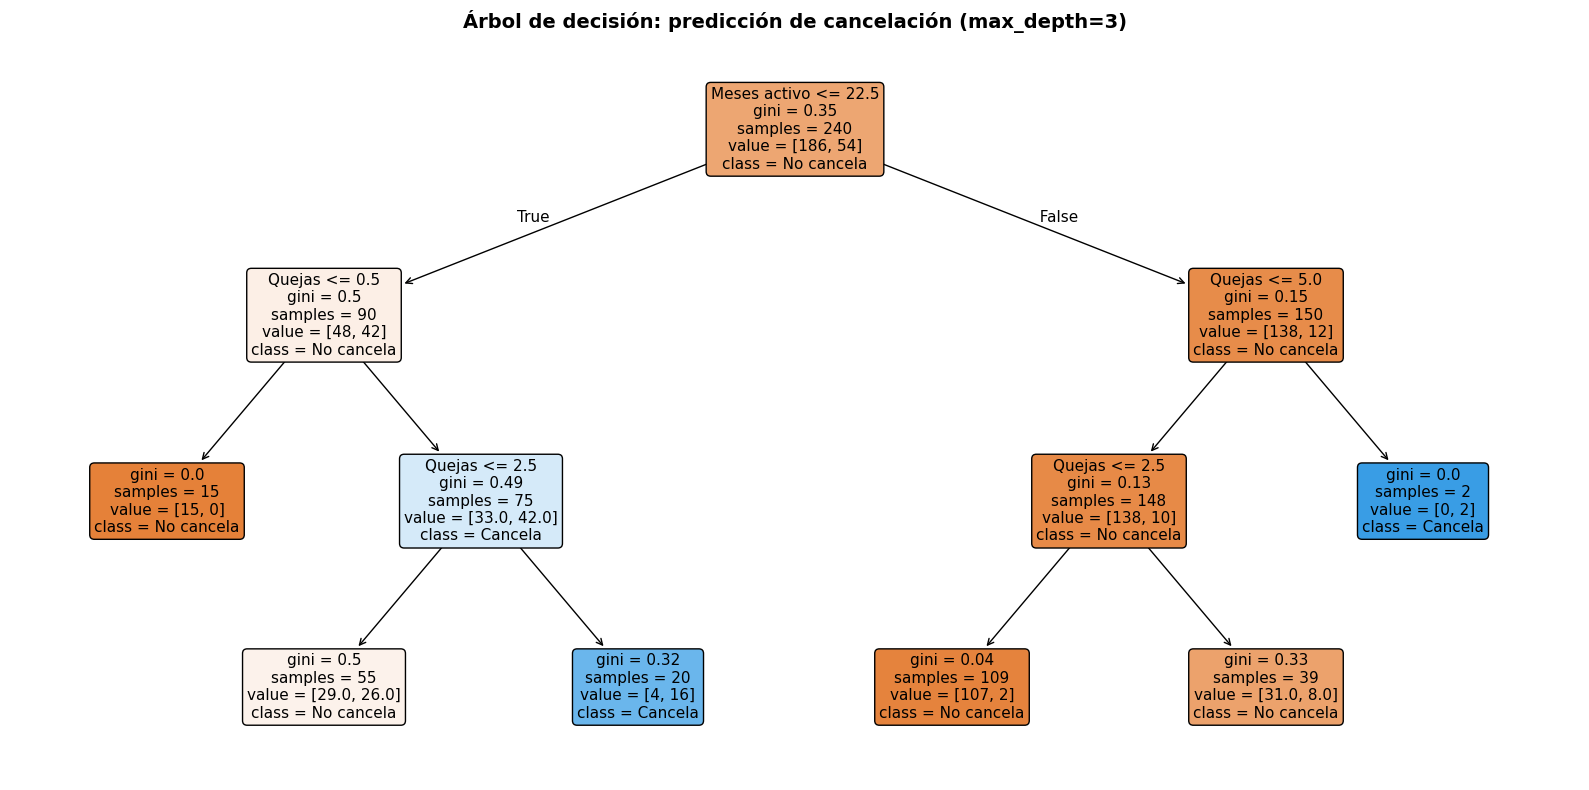

In [20]:
arbol = DecisionTreeClassifier(max_depth=3, random_state=42) # Instancia el clasificador de Árbol de Decisión limitando la profundidad máxima a 3 niveles
arbol.fit(X_train, y_train) # Entrena el modelo utilizando los datos del conjunto de entrenamiento
print("\nÁrbol entrenado")

plt.figure(figsize=(16, 8)) # Configura las dimensiones del lienzo del gráfico en pulgadas (ancho y alto)
plot_tree(
    arbol,
    feature_names=['Edad', 'Meses activo', 'Quejas', 'Gasto mensual', 'Plan'],
    class_names=['No cancela', 'Cancela'],
    filled=True,
    rounded=True,
    precision=2,
    fontsize=11
) # Dibuja la estructura del árbol etiquetando las variables, clases y aplicando formato visual
plt.title("Árbol de decisión: predicción de cancelación (max_depth=3)", fontsize=14, fontweight='bold') # Define el título principal de la figura con tamaño y estilo de fuente
plt.tight_layout() # Ajusta automáticamente los márgenes del gráfico para evitar que los elementos se superpongan
plt.show() # Despliega la figura generada en la pantalla

### 9. Evaluar el modelo

In [21]:
# Exactitud del modelo
predicciones = arbol.predict(X_test) # Realiza las predicciones de cancelación sobre el conjunto de prueba utilizando el árbol entrenado
exactitud = accuracy_score(y_test, predicciones) #Determina la exactitud del modelo

print(f"Exactitud en los datos de prueba: {exactitud:.2%}")

Exactitud en los datos de prueba: 80.00%


### 10. Predecir clientes nuevos
con df_nuevos

In [22]:
display(df_nuevos.head()) # Muestra las primeras 5 filas del DataFrame de clientes nuevos para inspeccionar la estructura inicial de los datos
print(df_nuevos.dtypes) # Imprime los tipos de datos asignados a cada columna de la tabla de clientes nuevos
print(df_nuevos['plan'].unique()) # Muestra los valores únicos de la columna plan en clientes nuevos para verificar posibles inconsistencias



,id_cliente,edad,meses_activo,quejas,plan,gasto_mensual
0,NV-01,24,2,4,Básico,4750
1,NV-02,45,48,0,Premium,10900
2,NV-03,31,6,2,Estándar,7400
3,NV-04,58,30,1,Estándar,7900
4,NV-05,37,12,5,Básico,5250


id_cliente       object
edad              int64
meses_activo      int64
quejas            int64
plan             object
gasto_mensual     int64
dtype: object
['Básico' 'Premium' 'Estándar']


In [23]:
# Se realiza ingeniería rápida repetida de lo que se hizo antes
df_nuevos['plan_num'] = df_nuevos['plan'].map({'Básico': 1, 'Estándar': 2, 'Premium': 3})

# Se declaran las variables independientes del dataset nuevo
X_nuevos = df_nuevos[['edad', 'meses_activo', 'quejas', 'gasto_mensual', 'plan_num']]

# Predicción
df_nuevos['prediccion'] = arbol.predict(X_nuevos) # Realiza la predicción sobre los clientes nuevos utilizando las variables transformadas
df_nuevos['resultado'] = df_nuevos['prediccion'].map({1: 'Cancela', 0: 'No cancela'}) # Mapea los valores numéricos predecidos (1 y 0) a etiquetas de texto explicativas

display(df_nuevos[['id_cliente', 'resultado']])

,id_cliente,resultado
0,NV-01,Cancela
1,NV-02,No cancela
2,NV-03,No cancela
3,NV-04,No cancela
4,NV-05,Cancela


In [24]:
importancias = pd.Series(arbol.feature_importances_, index=X.columns).sort_values(ascending=False) # Calcula e identifica la importancia de cada variable en el árbol y las ordena de mayor a menor
display(importancias) # Muestra en pantalla la serie con el peso relativo de cada característica en las decisiones del modelo

,0
meses_activo,0.506059
quejas,0.493941
edad,0.000000
gasto_mensual,0.000000
plan_num,0.000000


Como se pidió un max_depth de 3, el modelo detecta que las de más importancia son meses_activo y quejas, por eso sólo esas aparecen en el árbol.

## 11. Conclusión

Según el árbol de decisión, los clientes que tienden a cancelar son los que no han alcanzado más de 22.5 meses suscritos y tienen más quejas (>3). Los clientes con aproximadamente dos años de antigüedad no suelen cancelar a menos de que tengan muchas quejas. Se recomienda a StreamTico mejorar el servicio al cliente, priorizando clientes nuevos y ofrecerles seguimiento durante los primeros dos años, así como implementar un flujo de trabajo que optimice la resolución de quejas y permita evitarlas a futuro.